In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mssm.models import *
import pickle
import matplotlib
import copy as copy
import os
from matplotlib import font_manager

# Optionally load fonts (plots want "Source Sans 3")
font_path = None

if font_path is not None:
    font_files = font_manager.findSystemFonts(fontpaths=font_path)
    for font_file in font_files:
        font_manager.fontManager.addfont(font_file)

# Some settings for plots
cmp = matplotlib.colormaps['RdYlBu_r']
plt.rcParams["font.family"] = "Source Sans 3"
plt.rcParams["font.weight"] = "semibold"
plt.rcParams["font.size"] = 8
plt.rcParams["axes.titlesize"] = 9.5
plt.rcParams["axes.labelsize"] = 8
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 8
plt.rcParams["figure.titlesize"] = 11
math_font_size = 8
math_font = 'cm'

seed = 42*3
np_gen = np.random.default_rng(seed)

size_conv = 2.54
single_width = 6/size_conv
double_width = 12/size_conv
full_width = 19/size_conv

MGauss [0.04 0.26 0.07 0.05 0.07] [213   7 306 291 228]
Multinomial [0.67 2.46 2.23 0.69 2.07] [399 392 314 333 319]
ScaledT [0.39 2.86 2.22 0.38 0.6 ] [272 372 450 103 450]
PropHaz [0.1  2.35 0.47 1.62 2.07] [272 312 467 284 391]
MGauss [0.03 0.51 0.42 0.05 0.15] [188 152 138  20   7]
Multinomial [1.02 1.46 1.55 1.5  2.88] [147 289  58 452 217]
ScaledT [0.38 1.96 0.46 0.24 1.6 ] [421 247 128 129 299]
PropHaz [0.51 0.4  1.06 0.64 0.35] [287 351 111 261 351]


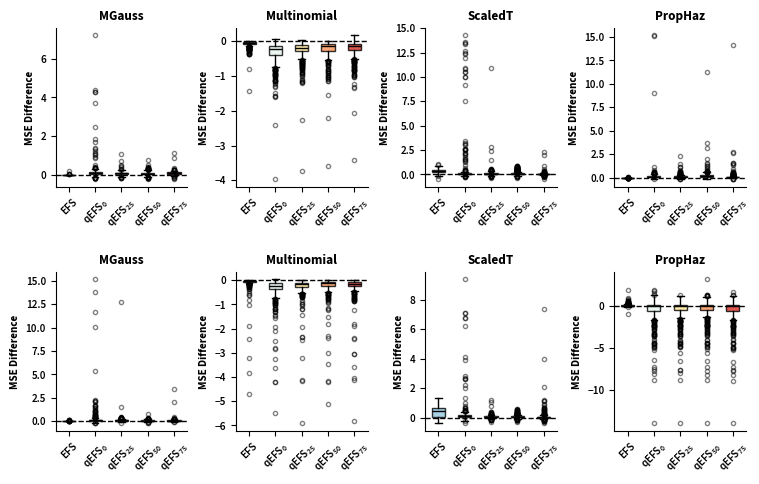

In [51]:
comp_cols = np.linspace(0.1,0.9,6)

fig = plt.figure(figsize=(full_width,2*single_width),layout='constrained')
axs = fig.subplots(2,4,gridspec_kw=dict(wspace=0.01,hspace=0.1)).flatten()

fam_names = ["MGauss", "Multinomial", "ScaledT", "PropHaz"]
n_sim = 500
sim = "sim1_gen"

axi = 0
for should_correlate in [False,True]:

    for fam_name in fam_names:

        ax = axs[axi]

        with open(f'./results/sim/{sim}/size:{n_sim}_fam:{fam_name}_corr:{should_correlate}.pickle', 'rb') as file:
            res = pickle.load(file)
        res_mgcv = pd.read_csv(f'./results/sim/{sim}/mgcv_size:{n_sim}_fam:{fam_name}_corr:{should_correlate}.csv')
        
        res_concat = np.concat((res_mgcv["mse"].values.reshape(-1,1),res["eta_mses"]),axis=1)
        std_concat = (res_concat-np.median(res_concat))/np.median(res_concat)
        ref = std_concat[:,0]

        ax.axhline(0,linestyle='dashed',color='black',linewidth=1)
        bplot = ax.boxplot(std_concat[:,1:] - ref[:,None],showfliers=True,widths=1/2,patch_artist=True,whis=1.5)
        argmaxs = np.argmax(std_concat[:,1:] - ref[:,None],axis=0)
        arg_max_vals = [res_concat[argmaxs[sidx],1+sidx] for sidx in range(len(argmaxs))]
        print(fam_name,np.round(arg_max_vals,decimals=2),argmaxs)

        plt.setp(bplot['fliers'],markersize=3,alpha=0.5)

        for pidx,(patch,line) in enumerate(zip(bplot["boxes"],bplot["medians"])):
            patch.set_facecolor(cmp(comp_cols[pidx+1]))
            patch.set_alpha(0.8)
            line.set_color("black")

        ax.set_ylabel("MSE Difference",math_fontfamily=math_font,size=math_font_size,fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(True)

        ax.set_xticklabels(["EFS",
                            "$\\mathregular{qEFS_{0}}$",
                            "$\\mathregular{qEFS_{25}}$",
                            "$\\mathregular{qEFS_{50}}$",
                            "$\\mathregular{qEFS_{75}}$"])
        
        ax.tick_params(axis='x', labelrotation=45)
        ax.tick_params(labelleft = True, left = True, right=False,labelright=False)
        ax.yaxis.set_label_position("left")
        ax.set_title(fam_name,fontweight='bold')

        axi += 1

#fig.text(0.5,1.05,"Uncorrelated Predictors",fontweight='bold',fontsize=plt.rcParams["figure.titlesize"],ha="center", va="top",transform=fig.transFigure,fontfamily="Source Sans 3")
#fig.text(0.5,0.5175,"Correlated Predictors",fontweight='bold',fontsize=plt.rcParams["figure.titlesize"],ha="center", va="top",transform=fig.transFigure,fontfamily="Source Sans 3")

plt.savefig(f"./results/plots/{sim}_main.pdf", format="pdf", bbox_inches='tight')
plt.show()